# Clase 24: Valuación de opciones exóticas - Asiáticas y con Barrera

> **Objetivo:** Entender qué hace “exótica” a una opción, calcular el precio de una opción asiática cuyo payoff depende del promedio del precio, y de una opción con barrera que se activa o desactiva al cruzar un nivel predefinido — ambas vía simulación Monte Carlo.
> 

---

## 1. ¿Qué es una opción exótica?

Una opción **estándar** (vanilla) tiene un payoff que depende únicamente del precio al vencimiento: $\max(S_T - K, 0)$.

Una opción **exótica** tiene un payoff que depende de la trayectoria completa del precio, o que incluye condiciones adicionales. No tienen solución analítica general. Monte Carlo es la herramienta natural.

Las más comunes en la práctica son las **asiáticas** (usadas en commodities y FX) y las **de barrera** (usadas en estructurados y coberturas corporativas).

---

## 2. Opciones Asiáticas

### Intuición

El payoff de una opción asiática depende del **promedio** del precio durante la vida de la opción, no del precio final. Hay dos variantes:

- **Average price:** $\max(\bar{S} - K, 0)$ donde $\bar{S}$ es el promedio
- **Average strike:** $\max(S_T - \bar{S}, 0)$

¿Por qué existen? Porque en mercados de commodities o FX, el precio en un solo día puede ser manipulado o muy volátil. El promedio es más representativo del valor “real” durante el período.

Son más **baratas** que las opciones vanilla equivalentes porque el promedio tiene menor varianza que el precio final.

### Implementación Monte Carlo

```python

```

### Visualización

```python

```

---

## 3. Opciones con Barrera

### Intuición

Una opción con barrera se activa o desactiva si el precio cruza un nivel predefinido B en cualquier momento de la vida de la opción. Hay cuatro tipos principales:

| Tipo | Descripción |
| --- | --- |
| **Up-and-out** | Call que desaparece si S sube por encima de B |
| **Up-and-in** | Call que nace solo si S sube por encima de B |
| **Down-and-out** | Put que desaparece si S baja por debajo de B |
| **Down-and-in** | Put que nace solo si S baja por debajo de B |

Son más **baratas** que las opciones vanilla porque hay escenarios donde el payoff es cero aunque la opción termine ITM.

### Relación de paridad

$$
\text{Up-and-in} + \text{Up-and-out} = \text{Vanilla}
$$

Si la barrera se cruza, una se activa y la otra se desactiva, juntas siempre valen lo mismo que la vanilla.

### Implementación Monte Carlo

```python

```

### Visualización

```python

```

> Conforme la barrera B se aleja del precio actual, el up-and-out call converge al precio de la vanilla: la probabilidad de tocar la barrera disminuye y la opción se comporta como una estándar.
> 

---

## Preguntas - actividad

- La opción asiática es más barata que la vanilla. ¿Siempre es así? ¿Puedes pensar en algún caso donde fueran igual de caras?
- Verificaste que up-and-in + up-and-out = vanilla. ¿Qué implica eso para el pricing? ¿Puedes usarlo para encontrar el precio de una si conoces la otra?
- Si la barrera B está muy cerca de S0, el up-and-out call casi no vale nada. ¿Por qué? ¿Y si la barrera está muy lejos?
- ¿Por qué Monte Carlo es especialmente apropiado para opciones exóticas? ¿Cuál es su limitación principal vs. soluciones analíticas?

In [2]:
# Asiaticas
import numpy as np
import pandas as pd 
from scipy.stats import norm 

# Parámetros

S0 = 670
K = 680
r = 0.04

sigma = 0.17
N = 30  #Numero de dias
T = N/365 #Tiempo al vencimiento
M = 10000 # Numero de simulaciones

dt = T/N

Z = np.random.standard_normal((M,N))

retornos = (r -0.5 * sigma ** 2) * dt + sigma *np.sqrt(dt) * Z

S_paths = S0 * np.exp(np.cumsum(retornos, axis = 1))
S_paths = np.insert(S_paths, 0, S0, axis = 1)

# Vector de precios al vencimiento
ST = S_paths[:, -1]

# Vector de precios promedio de fluctuación del subyacente
S_media = S_paths.mean(axis = 1)

europea = np.exp(-r * T) * np.maximum(ST - K, 0)

asiatica = np.exp(-r * T) * np.maximum(S_media - K, 0)


# analítica Black Scholes
d1 = (np.log(S0 / K) + (r + 0.5 * sigma **2) * T / sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
bs_call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print("Precio Asiatica:",asiatica.mean())
print("Precio Europea:",europea.mean())
print("Precio Black Scholes:",bs_call)


Precio Asiatica: 3.9260912595076225
Precio Europea: 9.61773812925728
Precio Black Scholes: 9.308744964731545


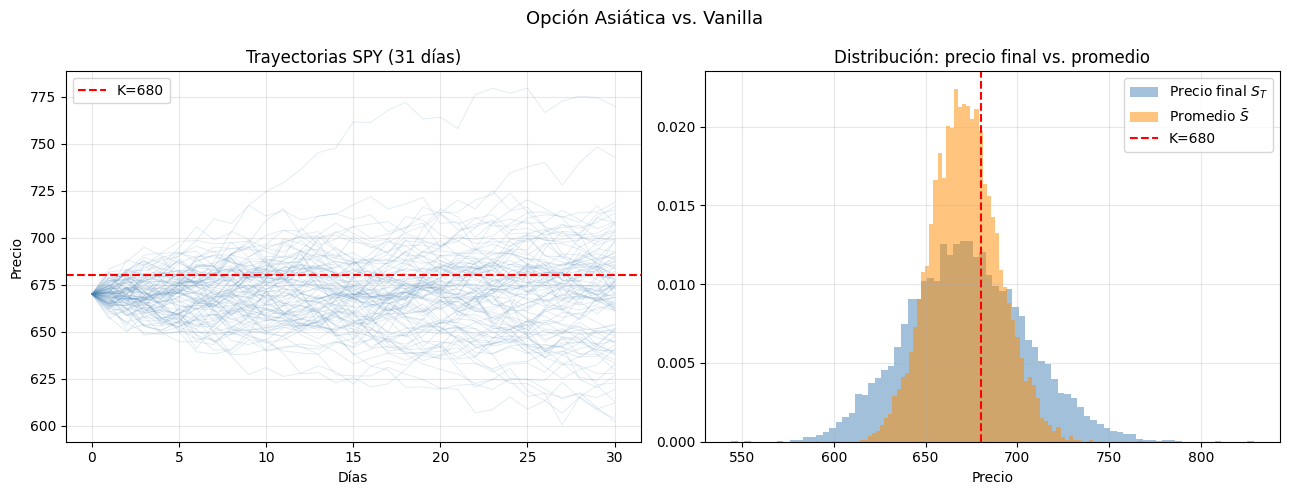

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias con el promedio marcado
for i in range(100):
    axes[0].plot(S_paths[i], alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].axhline(K, color='red', linestyle='--', linewidth=1.5, label=f'K={K}')
axes[0].set_title('Trayectorias SPY (31 días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución: precio final vs. promedio
axes[1].hist(ST,      bins=80, density=True, alpha=0.5,
             color='steelblue', label='Precio final $S_T$')
axes[1].hist(S_media, bins=80, density=True, alpha=0.5,
             color='darkorange', label='Promedio $\\bar{S}$')
axes[1].axvline(K, color='red', linestyle='--', label=f'K={K}')
axes[1].set_title('Distribución: precio final vs. promedio')
axes[1].set_xlabel('Precio')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Opción Asiática vs. Vanilla', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
B_up = 710

S_max = S_paths.max(axis=1)


# up and out
activa_up_and_out = (S_max < B_up)
call_up_and_out = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_out

# up and out
activa_up_and_in = (S_max > B_up)
call_up_and_in = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_in

print("up and out: ", call_up_and_out.mean())
print("up and in: ", call_up_and_in.mean())
print("europea", europea.mean())
print("comprobacion", call_up_and_out.mean() + call_up_and_in.mean()  )

up and out:  2.3547173515204833
up and in:  7.263020777736798
europea 9.61773812925728
comprobacion 9.617738129257281


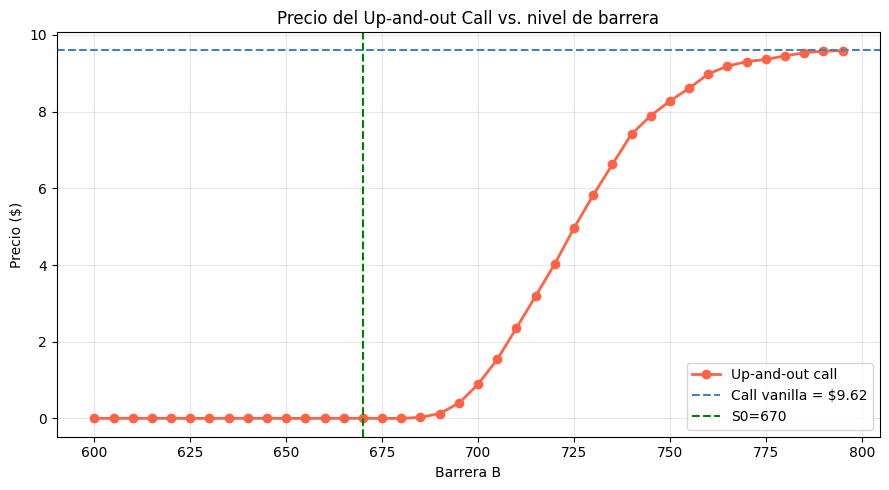

In [7]:
B_range = np.arange(600, 800, 5)   # barreras superiores
precios_uao = []

for b in B_range:
    s_max_b = S_paths.max(axis=1)
    precio  = np.exp(-r*T) * np.maximum(ST - K, 0) * (s_max_b < b)
    precios_uao.append(precio.mean())

plt.figure(figsize=(9, 5))
plt.plot(B_range, precios_uao, color='tomato', linewidth=2, marker='o',
         label='Up-and-out call')
plt.axhline(europea.mean(), color='steelblue', linestyle='--',
            linewidth=1.5, label=f'Call vanilla = ${europea.mean():.2f}')
plt.axvline(S0, color='green', linestyle='--', label=f'S0={S0}')
plt.xlabel('Barrera B')
plt.ylabel('Precio ($)')
plt.title('Precio del Up-and-out Call vs. nivel de barrera')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rep. 4. Checkpoint 5. Exóticas: Asiáticas y con Barrera

### Preguntas

- **La opción asiática es más barata que la vanilla. ¿Siempre es así? ¿Puedes pensar en algún caso donde fueran igual de caras?**

*Respuesta:*
Casi siempre la asiática es más barata porque sacar el promedio tiene menor varianza que agarrar el precio final. Serían igual de caras en un caso extremo donde la volatilidad del mercado fuera cero (o sea, el precio no se mueve) o si lit es una opción de un solo periodo, haciendo que el promedio y el precio final sean exactamente la misma cosa.

- **Verificaste que up-and-in + up-and-out = vanilla. ¿Qué implica eso para el pricing? ¿Puedes usarlo para encontrar el precio de una si conoces la otra?**

*Respuesta:*

Significa que como una se activa y la otra se desactiva al cruzar la barrera, juntas siempre van a valer lo mismo que una opción estándar. Para el pricing esto es súper útil porque si ya calculaste el precio de la vanilla (tipo con Black-Scholes) y conoces una de las de barrera, literal puedes sacar la otra por pura resta.

- **Si la barrera B está muy cerca de S0, el up-and-out call casi no vale nada. ¿Por qué? ¿Y si la barrera está muy lejos?**

*Respuesta:*

Si la barrera está muy cerca de S0, es casi seguro que el precio la va a tocar rapidísimo y la opción up-and-out va a desaparecer, por eso casi no vale nada. En cambio, si la pones lejísimos, la probabilidad de tocarla disminuye un buen y la opción converge para comportarse casi idéntico a una estándar.

- **¿Por qué Monte Carlo es especialmente apropiado para opciones exóticas? ¿Cuál es su limitación principal vs. soluciones analíticas?**

*Respuesta:*

Monte Carlo es súper apropiado porque las opciones exóticas dependen de tooooda la trayectoria completa del precio (son path-dependent), y como no tienen una solución analítica general, la simulación es la mejor salida. Su mayor limitación frente a soluciones analíticas es que solo te da una aproximación numérica y consume un buen de tiempo y poder computacional, mientras que una fórmula exacta te daría el precio de volada.